# 4차시 실습 — 평가 · 배포 및 서비스 제공 · 모니터링

**인공지능플랫폼 실습/설계 · 2026학년도 2학기**

---

## 이 실습의 목적

머신러닝 시스템 설계 7단계 중 **5~7단계**를 다룬다. 만든 모델을 **운영 가능한 시스템**으로 바꾼다.

| 단계 | 이름 | 이 노트북에서 하는 일 |
|---|---|---|
| 5 | 평가 | 지표 계산 · 임계값을 비용으로 결정 · 공정성 측정 |
| 6 | 배포 및 서비스 제공 | 모델 저장 · 배치 예측 서비스 클래스 구현 |
| 7 | 모니터링 및 인프라 | 드리프트 감지(PSI) · 재학습 트리거 · 모니터링 리포트 |

## 오늘의 한 문장

> **"모델의 성능"은 숫자 하나가 아니라, 어떤 결정을 어떤 비용으로 내릴 것인가에 대한 합의다.**

## 시작 조건

3차시에서 저장한 `hr_attrition_v1.pkl` 이 있으면 불러오고, 없으면 같은 설정으로 다시 학습한다.
**3차시를 못 했거나 파일이 없어도 그대로 진행할 수 있다.**

---

## 진행 안내 — 어디까지 수업 시간에 하는가

| 절 | 내용 | 구분 | 예상 시간 |
|---|---|---|---|
| 0 | 3차시 파이프라인 로드 | 수업 | 5분 |
| 1 | 혼동행렬과 지표 · 정확도의 함정 | **수업 (핵심)** | 15분 |
| 2 | ROC 곡선 · PR 곡선 | 수업 (코드 제공, 해석만) | 10분 |
| 3 | 임계값 스윕 | 수업 (코드 제공, 해석만) | 10분 |
| 4 | 비용 기반 임계값 · 민감도 분석 | **수업 (핵심)** | 20분 |
| 5 | top-K 와 최종 운영 임계값 결정 | **수업 (핵심)** | 15분 |
| 6 | 민감 속성 그룹별 공정성 평가 | **수업** | 15분 |
| 7 | 모델 저장 · 서빙 클래스 | 수업 (골격 제공) | 15분 |
| 8 | PSI 드리프트 감지 | **수업** | 15분 |
| 8-3 | 재학습과 롤백 | 읽기 (코드 제공) | 5분 |
| 9 | 월간 배치 작업 통합 실행 | 수업 (코드 제공) | 5분 |

> 막히면 각 절 끝의 **구제 셀**에서 `USE_RESCUE = True` 로 바꾸고 실행한다.
> 사용해도 감점하지 않는다. 어디서 왜 막혔는지만 제출 시 한 줄 적는다.


In [63]:
# ============================================================
# 0. 환경 설정 (Colab 에서 런타임을 다시 연결할 때마다 실행)
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 폰트 설정 (Colab · macOS · Windows 공통) ----------
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from matplotlib import ft2font
import os, glob, subprocess, platform

# ① 이름으로 찾아볼 후보 — 앞에서부터 '실제로 쓸 수 있는' 것을 고른다
FONT_CANDIDATES = [
    "NanumBarunGothic", "NanumGothic", "Nanum Gothic",          # Colab / Linux
    "Apple SD Gothic Neo", "AppleGothic",                       # macOS
    "Malgun Gothic",                                            # Windows
    "Noto Sans CJK KR", "Noto Sans KR",                         # 기타
]

# ② 이름으로 못 찾을 때(폰트 캐시가 오래된 경우) 직접 열어 볼 파일 경로
FONT_PATHS = {
    "Darwin": ["/System/Library/Fonts/AppleSDGothicNeo.ttc",
               "/System/Library/Fonts/Supplemental/AppleGothic.ttf"],
    "Windows": ["C:/Windows/Fonts/malgun.ttf", "C:/Windows/Fonts/NanumGothic.ttf"],
    "Linux": ["/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
              "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"],
}


def _has_hangul(path):
    """그 폰트 파일에 한글 글리프가 실제로 들어 있는가"""
    try:
        return ft2font.FT2Font(path).get_char_index(ord("가")) != 0
    except Exception:
        return False


def _usable(name):
    """그 이름으로 폰트 파일이 찾아지고, 한글까지 그릴 수 있는가"""
    try:
        path = fm.findfont(FontProperties(family=name), fallback_to_default=False)
    except Exception:
        return False                      # 이름만 있고 파일은 없는 경우
    return _has_hangul(path)


def setup_korean_font():
    """설치된 한글 폰트를 찾아 matplotlib 에 설정하고 그 이름을 반환한다."""
    font = next((n for n in FONT_CANDIDATES if _usable(n)), None)

    # Colab/Linux 에 한글 폰트가 없으면 나눔폰트를 설치한다
    if font is None and platform.system() == "Linux":
        if not glob.glob("/usr/share/fonts/truetype/nanum/*.ttf"):
            try:
                subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                               check=False, capture_output=True)
            except Exception:
                pass

    # 이름으로 못 찾으면 폰트 파일을 직접 등록한다 (캐시가 오래된 환경 대비)
    if font is None:
        paths = FONT_PATHS.get(platform.system(), [])
        paths += glob.glob("/usr/share/fonts/truetype/nanum/*.ttf")
        for path in paths:
            if os.path.exists(path) and _has_hangul(path):
                try:
                    fm.fontManager.addfont(path)
                    font = FontProperties(fname=path).get_name()
                    break
                except Exception:
                    continue

    if font:
        # sans-serif 목록 맨 앞에도 넣어 둔다 — 다른 라이브러리가 덮어써도 살아남도록
        plt.rcParams["font.family"] = font
        plt.rcParams["font.sans-serif"] = [font] + [
            f for f in plt.rcParams["font.sans-serif"] if f != font]
    else:
        print("주의: 한글 폰트를 찾지 못했습니다 — 그래프의 한글이 □ 로 보일 수 있습니다.")
        print("      Colab 이라면 런타임을 다시 시작한 뒤 이 셀을 한 번 더 실행하세요.")
    plt.rc("axes", unicode_minus=False)     # 마이너스 기호 깨짐 방지
    return font


KFONT = setup_korean_font()
sns.set_theme(style="whitegrid", font=KFONT or "sans-serif")
plt.rc("axes", unicode_minus=False)         # set_theme 뒤에 한 번 더 고정
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_STATE = 2026
DATA_URL = "http://joy-bae.github.io/HR-Employee-Attrition.csv"
print(f"환경 설정 완료 / pandas {pd.__version__} / 한글 폰트: {KFONT or '없음 (주의)'}")

환경 설정 완료 / pandas 3.0.3 / 한글 폰트: Apple SD Gothic Neo


---
# 0. 3차시 결과 불러오기


In [64]:
# 1. 비용 문제 있음 (퇴사자 면담하는 비용) -> 퇴사자 예측 모델 필요
import os, json, joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv(DATA_URL)
TARGET = "Attrition"

NUM_COLS = ["Income_M", "p_SalaryHike", "Age", "Dist", "Companies",
            "YearsAtCompany", "YearsSinceLastPromotion"]
ORD_COLS = ["Education", "JobLevel", "JobSatisfaction", "Env_Satisfaction",
            "RelationshipSatisfaction", "Performance", "StockOption", "WorkLifeBalance"]
CAT_COLS = ["Department", "Gender", "MaritalStatus", "OverTime"]


def add_features(data):
    d = data.copy()
    d["PromotionStall"] = d["YearsSinceLastPromotion"] / (d["YearsAtCompany"] + 1)
    d["JobHopRate"] = d["Companies"] / (d["Age"] - 18).clip(lower=1)
    d["IncomeVsLevel"] = d["Income_M"] / d.groupby("JobLevel")["Income_M"].transform("mean")
    d["BurnoutRisk"] = (d["OverTime"] == "Yes").astype(int) * (5 - d["WorkLifeBalance"])
    return d


NEW_FEATURES = ["PromotionStall", "JobHopRate", "IncomeVsLevel", "BurnoutRisk"]
NUM_ALL = NUM_COLS + NEW_FEATURES

df_fe = add_features(df)
X = df_fe[NUM_ALL + ORD_COLS + CAT_COLS]
y = df_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)


def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", MinMaxScaler())]), NUM_ALL),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
        ("ord", "passthrough", ORD_COLS),
    ])


if os.path.exists("hr_attrition_v1.pkl"):
    clf = joblib.load("hr_attrition_v1.pkl")
    print("3차시 파이프라인을 불러왔습니다.")
else:
    clf = Pipeline([("pre", make_preprocessor()),
                    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                 random_state=RANDOM_STATE))])
    clf.fit(X_train, y_train)
    print("저장된 파일이 없어 같은 설정으로 다시 학습했습니다.")

proba = clf.predict_proba(X_valid)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"검증 데이터 {len(y_valid)}건 / 실제 퇴사자 {int(y_valid.sum())}명 "
      f"({y_valid.mean():.1%})")
print(f"예측 퇴사자  {int(pred.sum())}명 "
      f"({pred.mean():.1%})")

3차시 파이프라인을 불러왔습니다.
검증 데이터 441건 / 실제 퇴사자 71명 (16.1%)
예측 퇴사자  135명 (30.6%)


---
# STEP 5 · 평가

## 1. 혼동행렬과 지표 — 정확도의 함정 확인 (수업 · 핵심)

|  | 예측: 재직(0) | 예측: 퇴사(1) |
|---|---|---|
| **실제: 재직(0)** | TN — 진음성 | **FP — 위양성** (헛된 면담) |
| **실제: 퇴사(1)** | **FN — 위음성** (놓친 퇴사자) | TP — 진양성 |

- 정확도 = (TP + TN) / 전체
- 정밀도 = TP / (TP + FP) — 퇴사라고 예측한 사람 중 실제 퇴사자의 비율
- 재현율 = TP / (TP + FN) — 실제 퇴사자 중 우리가 찾아낸 비율

**HR 사례에서 FN(놓친 퇴사자)의 비용이 FP(헛된 면담)의 비용보다 훨씬 크다 → 재현율 우선**


In [65]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             recall_score, precision_score, f1_score, roc_auc_score,
                             average_precision_score, classification_report)
from sklearn.dummy import DummyClassifier

# 1) 기준선 — 아무것도 학습하지 않고 전원 '재직'으로 예측한다
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_valid)

# 2) 기준선과 모델(임계값 0.5)을 같은 표에 나란히 놓는다
rows = []
for name, pr in [("기준선(전원 재직)", dummy_pred), ("모델(임계값 0.5)", pred)]:
    tn, fp, fn, tp = confusion_matrix(y_valid, pr, labels=[0, 1]).ravel()
    rows.append({"모델": name, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
                 "정확도": round(accuracy_score(y_valid, pr), 4),
                 "재현율": round(recall_score(y_valid, pr, zero_division=0), 4),
                 "정밀도": round(precision_score(y_valid, pr, zero_division=0), 4),
                 "F1": round(f1_score(y_valid, pr, zero_division=0), 4)})

compare = pd.DataFrame(rows)
print(compare.to_string(index=False))

# 3) 임계값과 무관한 순위 지표
print()
print(f"ROC-AUC : {roc_auc_score(y_valid, proba):.4f}   (무작위 = 0.5)")
print(f"PR-AUC  : {average_precision_score(y_valid, proba):.4f}"
      f"   (기준선 = 소수 클래스 비율 {y_valid.mean():.4f})")

print("\n[정확도의 함정]")
acc_base = accuracy_score(y_valid, dummy_pred)
acc_model = accuracy_score(y_valid, pred)
print(f"  기준선은 퇴사자를 한 명도 찾지 못하는데(재현율 0.0) 정확도는 {acc_base:.4f} 다.")
print(f"  모델의 정확도는 {acc_model:.4f} 로 기준선보다 {acc_base - acc_model:+.4f} 낮지만,")
print(f"  실제 퇴사자 {int(y_valid.sum())}명 중 {int(confusion_matrix(y_valid, pred).ravel()[3])}명을 찾아낸다.")
print("  → 불균형 데이터에서 정확도는 '다수 클래스를 얼마나 잘 맞추는가'에 지배된다.")

print("\n[PR-AUC 의 기준선이 왜 소수 클래스 비율인가]")
print("  확률을 무작위로 매기면 어떤 지점에서 잘라도 뽑힌 집단의 퇴사자 비율은 전체 비율과 같다.")
print(f"  즉 정밀도가 재현율과 무관하게 {y_valid.mean():.4f} 로 평평해진다 → 그 선이 PR 곡선의 바닥이다.")
print("  ROC 의 바닥은 클래스 비율과 무관하게 항상 0.5 이므로, 불균형에서는 PR 쪽이 더 정직하다.")

         모델  TP  FN  FP  TN    정확도    재현율    정밀도     F1
 기준선(전원 재직)   0  71   0 370 0.8390 0.0000 0.0000 0.0000
모델(임계값 0.5)  51  20  84 286 0.7642 0.7183 0.3778 0.4951

ROC-AUC : 0.8174   (무작위 = 0.5)
PR-AUC  : 0.5689   (기준선 = 소수 클래스 비율 0.1610)

[정확도의 함정]
  기준선은 퇴사자를 한 명도 찾지 못하는데(재현율 0.0) 정확도는 0.8390 다.
  모델의 정확도는 0.7642 로 기준선보다 +0.0748 낮지만,
  실제 퇴사자 71명 중 51명을 찾아낸다.
  → 불균형 데이터에서 정확도는 '다수 클래스를 얼마나 잘 맞추는가'에 지배된다.

[PR-AUC 의 기준선이 왜 소수 클래스 비율인가]
  확률을 무작위로 매기면 어떤 지점에서 잘라도 뽑힌 집단의 퇴사자 비율은 전체 비율과 같다.
  즉 정밀도가 재현율과 무관하게 0.1610 로 평평해진다 → 그 선이 PR 곡선의 바닥이다.
  ROC 의 바닥은 클래스 비율과 무관하게 항상 0.5 이므로, 불균형에서는 PR 쪽이 더 정직하다.


In [66]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — 기준선 예측과 지표표
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
    dummy_pred = dummy.predict(X_valid)

    rows = []
    for name, pr in [("기준선(전원 재직)", dummy_pred), ("모델(임계값 0.5)", pred)]:
        tn, fp, fn, tp = confusion_matrix(y_valid, pr).ravel()
        rows.append({"모델": name, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
                     "정확도": round(accuracy_score(y_valid, pr), 4),
                     "재현율": round(recall_score(y_valid, pr, zero_division=0), 4),
                     "정밀도": round(precision_score(y_valid, pr, zero_division=0), 4),
                     "F1": round(f1_score(y_valid, pr, zero_division=0), 4)})
    compare = pd.DataFrame(rows)
    print(compare.to_string(index=False))
    print()
    print(f"ROC-AUC : {roc_auc_score(y_valid, proba):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_valid, proba):.4f}"
          f"   (PR-AUC 의 기준선 = 소수 클래스 비율 {y_valid.mean():.4f})")

    print('구제 코드를 사용했습니다 — 기준선 예측과 지표표')

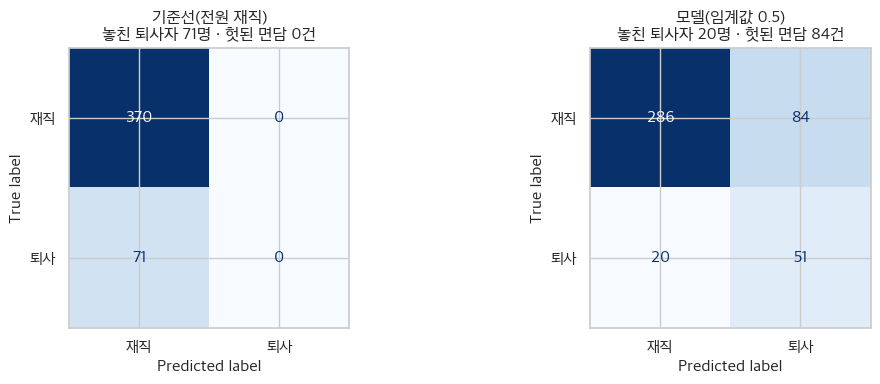

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pr) in zip(axes, [("기준선(전원 재직)", dummy_pred), ("모델(임계값 0.5)", pred)]):
    cm = confusion_matrix(y_valid, pr)
    ConfusionMatrixDisplay(cm, display_labels=["재직", "퇴사"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\n놓친 퇴사자 {fn}명 · 헛된 면담 {fp}건")
plt.tight_layout(); plt.show()

### [작성] 이 표를 읽는 법

정확도 기준과 재현율 기준에서 결론이 어떻게 달라지는지, 위 수치를 인용해 3~4문장으로 쓰라.



---
## 2. ROC 곡선과 PR 곡선 (수업 · 코드 제공)

두 지표는 **임계값과 무관**하다. "확률 순위를 얼마나 잘 매기는가"를 본다.

- **ROC 곡선**: x축 = 위양성률(FPR), y축 = 재현율(TPR). 무작위 = 0.5, 완벽 = 1.0
- **PR 곡선**: x축 = 재현율, y축 = 정밀도. 기준선 = 소수 클래스 비율

**그리기 전에 답해 보라** — 우리 데이터는 재직자가 84%, 퇴사자가 16%다.
ROC 곡선의 x축(FPR)은 **재직자 중 오탐 비율**인데, 재직자가 이렇게 많으면 FPR 은 잘 움직일까?
두 곡선 중 어느 쪽이 이 모델의 약점을 더 정직하게 드러낼 것 같은가?


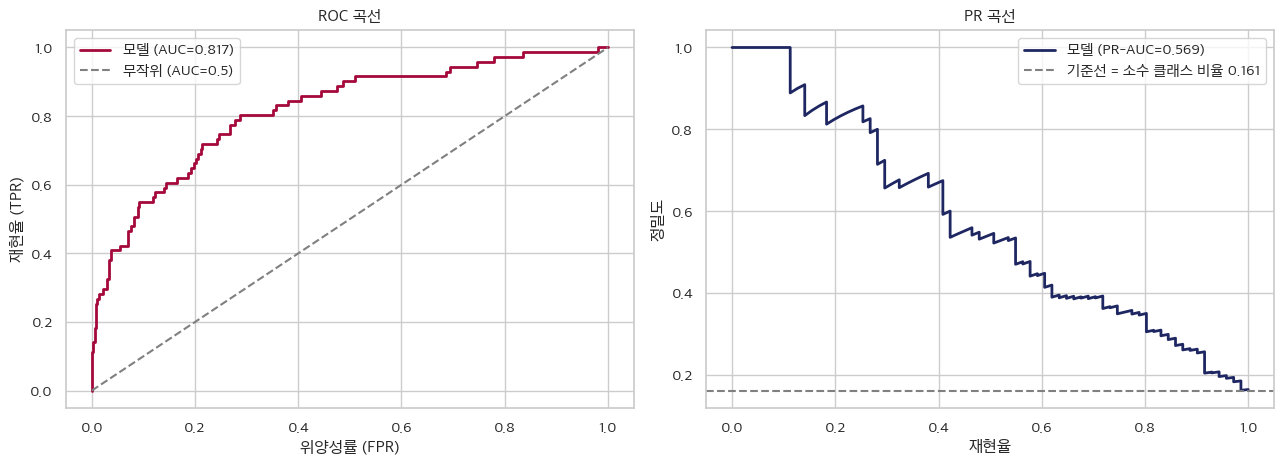

In [68]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_valid, proba)
prec, rec, _ = precision_recall_curve(y_valid, proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(fpr, tpr, color="#A5093B", lw=2,
             label=f"모델 (AUC={roc_auc_score(y_valid, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="무작위 (AUC=0.5)")
axes[0].set_xlabel("위양성률 (FPR)"); axes[0].set_ylabel("재현율 (TPR)")
axes[0].set_title("ROC 곡선"); axes[0].legend()

axes[1].plot(rec, prec, color="#1E2761", lw=2,
             label=f"모델 (PR-AUC={average_precision_score(y_valid, proba):.3f})")
axes[1].axhline(y_valid.mean(), ls="--", color="gray",
                label=f"기준선 = 소수 클래스 비율 {y_valid.mean():.3f}")
axes[1].set_xlabel("재현율"); axes[1].set_ylabel("정밀도")
axes[1].set_title("PR 곡선"); axes[1].legend()

plt.tight_layout(); plt.show()

### [작성] 두 곡선을 비교하고 답하라

1. ROC-AUC 와 PR-AUC 중 어느 쪽 숫자가 더 높은가? 왜 그런가?
2. 두 지표 중 이 모델의 성능을 더 보수적으로(=정직하게) 보여주는 쪽은 어느 쪽인가?
3. 만약 퇴사자 비율이 16%가 아니라 50%였다면 두 지표의 차이는 커질까, 작아질까?

**답**:


* ROC 곡선 (데이터가 균형적일 때 유리):

    * 양성(퇴직자)을 맞추는 비율(재현율)과 음성(재직자)을 잘못 예측하는 비율(위양성률, FPR)을 비교합니다.

    * 재직자(다수 클래스) 데이터가 압도적으로 많으면, 모델이 오탐(False Positive)을 많이 내더라도 분모가 워낙 커서 위양성률 수치가 낮게 유지됩니다. 이로 인해 전체적인 성능 곡선(AUC)이 실제보다 높게 부풀려지는 과대평가 착시가 발생하기 쉽습니다.

* PR 곡선 (데이터가 불균형할 때 유리):

    * 모델이 퇴직자라고 예측한 대상 중 실제 퇴직자의 비율(정밀도)과 실제 퇴직자 중 맞춘 비율(재현율)을 비교합니다.

    * 계산식에 다수 클래스를 잘 맞춘 건수(진음성, True Negative)가 아예 포함되지 않고 오직 타겟인 '소수 클래스(퇴직자)'에만 집중합니다. 오탐이 늘어나면 정밀도가 즉각적으로 하락하므로 모델의 약점이 그래프에 투명하게 드러납니다.

---
## 3. 임계값(threshold) — 확률을 결정으로 바꾸는 손잡이 (수업 · 코드 제공)

모델은 확률을 출력한다. **"퇴사 위험"이라고 부를 기준선은 모델이 아니라 우리가 정한다.**

`sklearn` 의 `predict()` 는 임계값 0.5 를 쓴다. **그런데 0.5 는 어디서 온 숫자인가?**
아래 표를 만들어 보고, 0.5 가 이 문제에 적절한 값인지 스스로 판단해 보라.
* FP : 잘못 사용된 면담비용
* FN : 놓친 퇴사자수
* 실제 퇴사자 : TP+FN

In [69]:
# arange(start, end, step)
thresholds = np.arange(0.05, 0.96, 0.05)
sweep = []
for t in thresholds:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, p, labels=[0, 1]).ravel()
    sweep.append({"임계값": round(t, 2), "면담 대상 수": int(p.sum()),
                  "TP": tp, "FN": fn, "FP": fp,
                  "재현율": round(recall_score(y_valid, p, zero_division=0), 4),
                  "정밀도": round(precision_score(y_valid, p, zero_division=0), 4),
                  "F1": round(f1_score(y_valid, p, zero_division=0), 4),
                  "정확도": round(accuracy_score(y_valid, p), 4)})
sweep_df = pd.DataFrame(sweep)
sweep_df

,임계값,면담 대상 수,TP,FN,FP,재현율,정밀도,F1,정확도
0,0.05,425,70,1,355,0.9859,0.1647,0.2823,0.1927
1,0.10,397,70,1,327,0.9859,0.1763,0.2991,0.2562
2,0.15,354,68,3,286,0.9577,0.1921,0.3200,0.3447
3,0.20,320,66,5,254,0.9296,0.2062,0.3376,0.4127
4,0.25,283,65,6,218,0.9155,0.2297,0.3672,0.4921
5,0.30,250,64,7,186,0.9014,0.2560,0.3988,0.5624
6,0.35,221,61,10,160,0.8592,0.2760,0.4178,0.6145
7,0.40,190,58,13,132,0.8169,0.3053,0.4444,0.6712
8,0.45,159,56,15,103,0.7887,0.3522,0.4870,0.7324
9,0.50,135,51,20,84,0.7183,0.3778,0.4951,0.7642


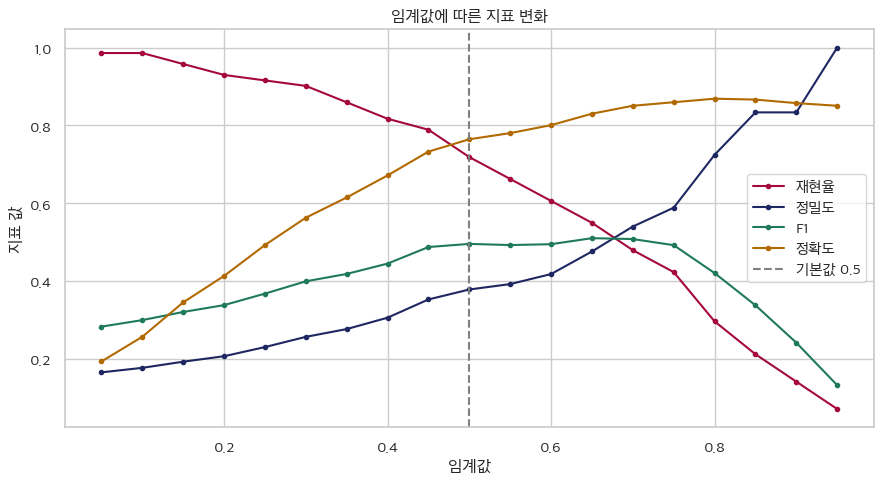

관찰: 임계값을 낮추면 재현율은 오르고 정밀도는 내려간다 — 둘은 서로 맞바뀐다.
      그렇다면 어느 지점을 골라야 하는가? 지표만 봐서는 정할 수 없다.
      → 다음 절: 비용으로 정한다.


In [70]:
plt.figure(figsize=(9, 5))
for col, color in [("재현율", "#A5093B"), ("정밀도", "#1E2761"),
                   ("F1", "#1F7A5A"), ("정확도", "#B26A00")]:
    plt.plot(sweep_df["임계값"], sweep_df[col], marker="o", ms=3, label=col, color=color)
plt.axvline(0.5, ls="--", color="gray", label="기본값 0.5")
plt.xlabel("임계값"); plt.ylabel("지표 값")
plt.title("임계값에 따른 지표 변화")
plt.legend(); plt.tight_layout(); plt.show()

print("관찰: 임계값을 낮추면 재현율은 오르고 정밀도는 내려간다 — 둘은 서로 맞바뀐다.")
print("      그렇다면 어느 지점을 골라야 하는가? 지표만 봐서는 정할 수 없다.")
print("      → 다음 절: 비용으로 정한다.")

---
## 4. 임계값을 비용으로 결정한다 (수업 · 핵심)

지표를 최대화하는 대신 **총비용을 최소화**하는 임계값을 찾는다.
이것이 "ML 목표"와 "비즈니스 목표"를 다시 잇는 지점이다.

| 오류 | 의미 | 인사팀 추정 비용 |
|---|---|---|
| FN | 퇴사자를 놓침 → 채용·교육·공백 | 1인당 약 2,000만 원 |
| FP | 헛된 면담 → 관리자 시간 | 1건당 약 20만 원 |

→ **비용비 100 : 1**


기본 임계값 0.50 → 총비용     41,680 만 원   (FN 20명 × 2000 + FP 84건 × 20)
최적 임계값 0.03 → 총비용      7,340 만 원   (FN 0명 × 2000 + FP 367건 × 20)
절감액                34,340 만 원   (82.4% 감소)
면담 대상 수      135명 → 438명
기본값 0.5의 비용 : 41,680 만 원, 최적 임계값 0.03의 비용 : 7,340 만 원


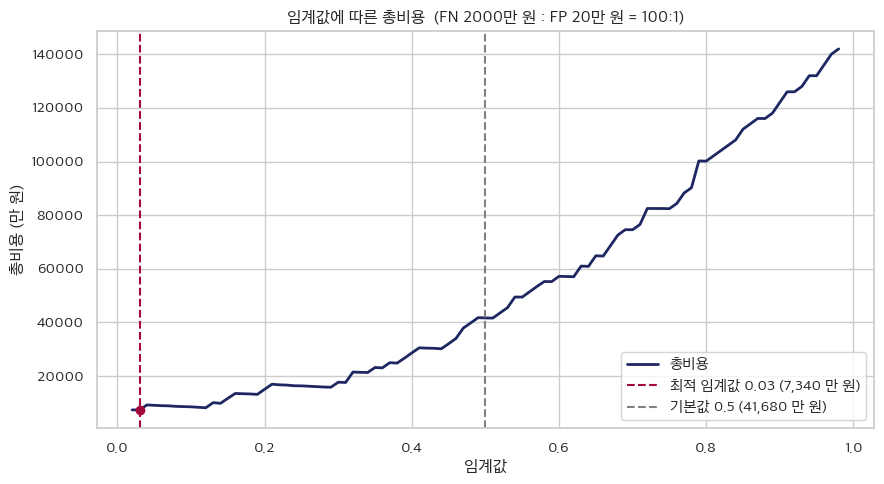

→ 비용 곡선의 최솟값은 지표(F1·정확도)의 최댓값과 같은 자리가 아니다.
  임계값은 '지표를 최대화하는 값'이 아니라 '비용 구조가 가리키는 값'이다.


In [94]:
COST_FN = 2000      # 단위: 만 원
COST_FP = 20


def total_cost(y_true, y_prob, t, c_fn=COST_FN, c_fp=COST_FP):
    """임계값 t 에서의 총비용 = FN 건수 × c_fn + FP 건수 × c_fp"""
    p = (np.asarray(y_prob) >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, p, labels=[0, 1]).ravel()
    return fn * c_fn + fp * c_fp


# 임계값을 0.02~0.98 까지 0.01 간격으로 움직이며 총비용을 계산한다
grid = np.arange(0.02, 0.99, 0.01)
costs = np.array([total_cost(y_valid, proba, t) for t in grid])

best_t = float(grid[costs.argmin()])
best_cost = float(costs.min())
cost_05 = float(total_cost(y_valid, proba, 0.5))

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_valid, (proba >= best_t).astype(int),
                                          labels=[0, 1]).ravel()
tn_5, fp_5, fn_5, tp_5 = confusion_matrix(y_valid, (proba >= 0.5).astype(int),
                                          labels=[0, 1]).ravel()

print(f"기본 임계값 0.50 → 총비용 {cost_05:>10,.0f} 만 원   (FN {fn_5}명 × {COST_FN} + FP {fp_5}건 × {COST_FP})")
print(f"최적 임계값 {best_t:.2f} → 총비용 {best_cost:>10,.0f} 만 원   (FN {fn_b}명 × {COST_FN} + FP {fp_b}건 × {COST_FP})")
print(f"절감액            {cost_05 - best_cost:>10,.0f} 만 원   ({(cost_05 - best_cost) / cost_05:.1%} 감소)")
print(f"면담 대상 수      {int((proba >= 0.5).sum())}명 → {int((proba >= best_t).sum())}명")
print(f"기본값 0.5의 비용 : {cost_05:,.0f} 만 원, 최적 임계값 {best_t:.2f}의 비용 : {best_cost:,.0f} 만 원")

plt.figure(figsize=(9, 5))
plt.plot(grid, costs, color="#1E2761", lw=2, label="총비용")
plt.axvline(best_t, color="#A5093B", ls="--",
            label=f"최적 임계값 {best_t:.2f} ({best_cost:,.0f} 만 원)")
plt.axvline(0.5, color="gray", ls="--", label=f"기본값 0.5 ({cost_05:,.0f} 만 원)")
plt.scatter([best_t], [best_cost], color="#A5093B", zorder=5)
plt.xlabel("임계값"); plt.ylabel("총비용 (만 원)")
plt.title(f"임계값에 따른 총비용  (FN {COST_FN}만 원 : FP {COST_FP}만 원 = {COST_FN // COST_FP}:1)")
plt.legend(); plt.tight_layout(); plt.show()

print("→ 비용 곡선의 최솟값은 지표(F1·정확도)의 최댓값과 같은 자리가 아니다.")
print("  임계값은 '지표를 최대화하는 값'이 아니라 '비용 구조가 가리키는 값'이다.")

### 실습 4-1. 비용 추정이 틀렸다면? — 민감도 분석

비용비는 인사팀의 **추정치**다. 추정이 틀렸을 때 결론이 얼마나 달라지는지 확인해야 한다.


In [72]:
# 비용비를 바꿔 가며 최적 임계값이 어디로 움직이는지 본다 (민감도 분석)
# class_weight="balanced" 는 소수 클래스를 n0/n1 배로 키워 학습한 것과 같다.
# 그래서 이 모델의 확률은 '진짜 확률'보다 부풀려져 있다 — 이론값과 비교하려면 이 배수가 필요하다.
w_ratio = float((y_train == 0).sum() / (y_train == 1).sum())

sens_rows = []
for ratio in [5, 10, 20, 50, 100, 200]:
    c = np.array([total_cost(y_valid, proba, t, c_fn=ratio, c_fp=1) for t in grid])
    t_opt = float(grid[c.argmin()])
    p = (proba >= t_opt).astype(int)

    t_theory = 1 / (ratio + 1)                       # 확률이 잘 보정된 경우의 이론값
    odds_adj = (1 / ratio) * w_ratio                 # balanced 가중치만큼 승산을 되돌린다
    t_theory_adj = odds_adj / (1 + odds_adj)         # 이 모델의 점수 척도로 옮긴 이론값

    sens_rows.append({"FN:FP 비용비": f"{ratio}:1", "최적 임계값": round(t_opt, 2),
                      "이론값(보정된 확률)": round(t_theory, 3),
                      "이론값(balanced 반영)": round(t_theory_adj, 3),
                      "면담 대상 수": int(p.sum()),
                      "재현율": round(recall_score(y_valid, p, zero_division=0), 3),
                      "정밀도": round(precision_score(y_valid, p, zero_division=0), 3)})

sens_df0 = pd.DataFrame(sens_rows)
print(sens_df0.to_string(index=False))

print("\n[비용비가 커지면 임계값은 어느 방향으로 움직이는가]")
print("  → 낮아진다. 따라서 면담 대상은 늘고 재현율은 오르며 정밀도는 떨어진다.")

print("\n[왜 그런가]")
print("  한 명을 더 부를지는 '부르지 않아 놓칠 기대비용 p×FN' 과")
print("  '불렀는데 헛수고일 기대비용 (1-p)×FP' 의 비교다. 둘이 같아지는 p 가 최적 임계값이므로")
print("  확률이 잘 보정돼 있다면  t* = FP / (FN + FP) = 1 / (비용비 + 1) 이다.")

print("\n[표의 세 값이 왜 서로 다른가 — 중요한 함정]")
print(f"  이 모델은 class_weight='balanced' 로 학습했다. 소수 클래스를 {w_ratio:.1f}배로 키운 셈이므로")
print("  출력 확률은 실제 퇴사 확률보다 부풀려져 있다(보정되지 않았다).")
print("  그래서 '이론값(보정된 확률)' 열을 그대로 쓰면 필요 이상으로 낮은 임계값을 고르게 된다.")
print("  승산을 되돌린 '이론값(balanced 반영)' 열이 실제 최적값과 훨씬 가깝다.")
print("  남은 차이는 검증 441건으로 argmin 을 찾는 데서 오는 표본 잡음이다.")
print("  → 확률을 '숫자 그대로' 비용 계산에 쓰려면 먼저 보정(calibration)이 필요하다.")

print("\n[여기서 확인할 것]")
print("  추정치인 비용비를 20:1 로 보느냐 100:1 로 보느냐에 따라 면담 인원이 몇 배로 달라진다.")
print("  즉 이 시스템의 운영점은 모델 성능보다 '비용 추정의 정확도'에 더 민감하다.")

FN:FP 비용비  최적 임계값  이론값(보정된 확률)  이론값(balanced 반영)  면담 대상 수   재현율   정밀도
      5:1    0.45        0.167             0.510      159 0.789 0.352
     10:1    0.44        0.091             0.342      166 0.803 0.343
     20:1    0.29        0.048             0.206      257 0.915 0.253
     50:1    0.12        0.020             0.094      379 0.986 0.185
    100:1    0.03        0.010             0.049      438 1.000 0.162
    200:1    0.03        0.005             0.025      438 1.000 0.162

[비용비가 커지면 임계값은 어느 방향으로 움직이는가]
  → 낮아진다. 따라서 면담 대상은 늘고 재현율은 오르며 정밀도는 떨어진다.

[왜 그런가]
  한 명을 더 부를지는 '부르지 않아 놓칠 기대비용 p×FN' 과
  '불렀는데 헛수고일 기대비용 (1-p)×FP' 의 비교다. 둘이 같아지는 p 가 최적 임계값이므로
  확률이 잘 보정돼 있다면  t* = FP / (FN + FP) = 1 / (비용비 + 1) 이다.

[표의 세 값이 왜 서로 다른가 — 중요한 함정]
  이 모델은 class_weight='balanced' 로 학습했다. 소수 클래스를 5.2배로 키운 셈이므로
  출력 확률은 실제 퇴사 확률보다 부풀려져 있다(보정되지 않았다).
  그래서 '이론값(보정된 확률)' 열을 그대로 쓰면 필요 이상으로 낮은 임계값을 고르게 된다.
  승산을 되돌린 '이론값(balanced 반영)' 열이 실제 최적값과 훨씬 가깝다.
  남은 차이는 검증 441건으로 argmin 을 찾는 데서 오는 표본 잡음

In [73]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — total_cost() 와 최적 임계값 탐색
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    def total_cost(y_true, y_prob, t, c_fn=COST_FN, c_fp=COST_FP):
        p = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, p, labels=[0, 1]).ravel()
        return fn * c_fn + fp * c_fp

    grid = np.arange(0.02, 0.99, 0.01)
    costs = np.array([total_cost(y_valid, proba, t) for t in grid])
    best_t = float(grid[costs.argmin()])
    print("최적 임계값:", round(best_t, 2), "/ 총비용:", f"{costs.min():,.0f} 만 원")
    print('구제 코드를 사용했습니다 — total_cost() 와 최적 임계값 탐색')

In [74]:
sens = []
for ratio in [5, 10, 20, 50, 100, 200]:
    c = np.array([total_cost(y_valid, proba, t, c_fn=ratio, c_fp=1) for t in grid])
    t_opt = float(grid[c.argmin()])
    p = (proba >= t_opt).astype(int)
    sens.append({"FN:FP 비용비": f"{ratio}:1", "최적 임계값": round(t_opt, 2),
                 "면담 대상 수": int(p.sum()),
                 "재현율": round(recall_score(y_valid, p, zero_division=0), 3),
                 "정밀도": round(precision_score(y_valid, p, zero_division=0), 3)})
sens_df = pd.DataFrame(sens)
print(sens_df.to_string(index=False))
print()
print("→ 비용비가 커질수록 임계값이 낮아지고 면담 대상이 늘어난다.")
print("  '지표를 최대화'하는 것이 아니라 '비용 구조를 반영'하는 것이 임계값 결정이다.")

FN:FP 비용비  최적 임계값  면담 대상 수   재현율   정밀도
      5:1    0.45      159 0.789 0.352
     10:1    0.44      166 0.803 0.343
     20:1    0.29      257 0.915 0.253
     50:1    0.12      379 0.986 0.185
    100:1    0.03      438 1.000 0.162
    200:1    0.03      438 1.000 0.162

→ 비용비가 커질수록 임계값이 낮아지고 면담 대상이 늘어난다.
  '지표를 최대화'하는 것이 아니라 '비용 구조를 반영'하는 것이 임계값 결정이다.


### 실습 4-2. 그래서 몇 명을 면담하게 되는가

비용 계산이 찾아 준 임계값을 그대로 적용하면 **이번 달 면담 대상이 몇 명이 되는지** 확인해 보라.
인사팀이 실제로 감당할 수 있는 숫자인가?


In [75]:
n_selected = int((proba >= best_t).sum())
print(f"제약 없는 최적 임계값 {best_t:.2f} → 면담 대상 {n_selected}명 "
      f"(검증 {len(y_valid)}명 중 {n_selected / len(y_valid):.1%})")
print()
print("이 인원을 인사팀이 한 달에 면담할 수 있는가?")

제약 없는 최적 임계값 0.03 → 면담 대상 438명 (검증 441명 중 99.3%)

이 인원을 인사팀이 한 달에 면담할 수 있는가?


### 방금 무슨 일이 일어났는가 — 비용 최적화의 퇴화

FN 비용이 FP 비용의 100배라면 "일단 다 불러서 면담하는 것"이 **수학적으로는 최적**이다.
그래서 최적 임계값이 극단적으로 낮아지고, 거의 전원이 면담 대상이 된다.

**이것은 계산 오류가 아니라, 비용 모형이 무언가를 빠뜨렸다는 신호다.**

빠뜨린 것이 무엇인지 생각해 보라.

- 인사팀의 면담 여력은 무한한가? (월 30~50명이 현실이다)
- 전원 면담은 면담 자체의 의미를 없애고 직원의 불신을 부른다 — 이 비용은 모형에 들어 있었는가?

→ 실제 운영 임계값은 **"비용 최소화 + 운영 가능 인원 제약"** 으로 정해야 한다.
다음 절의 top-K 방식이 그 제약을 직접 다루는 방법이다.


---
## 5. 상위 K명(top-K) 과 최종 운영 임계값 (수업 · 핵심)

> "이번 달 인사팀이 면담할 수 있는 인원은 30명이다."

그렇다면 임계값이 아니라 **인원 수**가 기준이 된다. 이때의 지표는 `Precision@K`, `Recall@K` 이다.
(5차시 이후 검색·추천 시스템에서 쓰는 지표와 동일하다.)


In [ ]:
# argmin 은 min값이 있을 때 그 인덱스를 반환한다. 따라서 최적 임계값이 0.5보다 낮으면 면담 대상이 늘어난다.
# argsort(-proba)[:k] 은 확률 내림차순으로 정렬했을 때 상위 k개의 위치를 반환한다.
# argsort는 yprob을 오름차순으로 정렬한 인덱스를 반환하므로, -y_prob를 넣어주면 내림차순이 된다.

def precision_recall_at_k(y_true, y_prob, k):
    """확률 상위 k명에 대한 Precision@K, Recall@K 를 반환"""
    y_true = np.asarray(y_true)
    idx = np.argsort(-np.asarray(y_prob))[:k]    # 확률 내림차순 상위 k개의 위치
    hit = int(y_true[idx].sum())                 # 그 안에 든 실제 퇴사자 수
    return hit / k, hit / int(y_true.sum())


base_rate = float(y_valid.mean())
rows = []
for k in [10, 20, 30, 50, 80, 120]:
    p_at_k, r_at_k = precision_recall_at_k(y_valid, proba, k)
    hit = int(round(p_at_k * k))
    rows.append({"K (면담 인원)": k,
                 "Precision@K": round(p_at_k, 3),
                 "Recall@K": round(r_at_k, 3),
                 "찾아낸 퇴사자": hit,
                 "무작위 기댓값": round(k * base_rate, 1),
                 "향상 배수(lift)": round(p_at_k / base_rate, 2)})

topk_df0 = pd.DataFrame(rows)
print(topk_df0.to_string(index=False))

print(f"\n전체 퇴사자 {int(y_valid.sum())}명 / 검증 대상 {len(y_valid)}명 (퇴사율 {base_rate:.1%})")
print("→ 무작위로 30명을 뽑으면 기댓값은 "
      f"{30 * base_rate:.1f}명, 모델 상위 30명에는 "
      f"{int(round(precision_recall_at_k(y_valid, proba, 30)[0] * 30))}명이 들어 있다.")
print("  K 가 커질수록 Recall@K 는 오르지만 Precision@K 는 떨어진다 — 여기서도 같은 교환관계다.")
print("  임계값을 정하는 대신 'K명'을 정하면, 운영 부하가 매달 일정하다는 장점이 생긴다.")

 K (면담 인원)  Precision@K  Recall@K  찾아낸 퇴사자  무작위 기댓값  향상 배수(lift)
        10        0.900     0.127        9      1.6         5.59
        20        0.850     0.239       17      3.2         5.28
        30        0.700     0.296       21      4.8         4.35
        50        0.600     0.423       30      8.0         3.73
        80        0.487     0.549       39     12.9         3.03
       120        0.392     0.662       47     19.3         2.43

전체 퇴사자 71명 / 검증 대상 441명 (퇴사율 16.1%)
→ 무작위로 30명을 뽑으면 기댓값은 4.8명, 모델 상위 30명에는 21명이 들어 있다.
  K 가 커질수록 Recall@K 는 오르지만 Precision@K 는 떨어진다 — 여기서도 같은 교환관계다.
  임계값을 정하는 대신 'K명'을 정하면, 운영 부하가 매달 일정하다는 장점이 생긴다.


In [77]:
def precision_recall_at_k(y_true, y_prob, k):
    idx = np.argsort(-y_prob)[:k]                 # 확률 상위 k명
    hit = int(np.asarray(y_true)[idx].sum())
    return hit / k, hit / int(np.asarray(y_true).sum())


rows = []
for k in [10, 20, 30, 50, 80, 120]:
    p_at_k, r_at_k = precision_recall_at_k(y_valid, proba, k)
    rows.append({"K (면담 인원)": k, "Precision@K": round(p_at_k, 3),
                 "Recall@K": round(r_at_k, 3),
                 "찾아낸 퇴사자": int(round(r_at_k * y_valid.sum()))})
topk_df = pd.DataFrame(rows)
print(topk_df.to_string(index=False))
print()
print(f"전체 퇴사자 {int(y_valid.sum())}명 중 상위 30명만 면담해도 "
      f"{topk_df.loc[topk_df['K (면담 인원)']==30, '찾아낸 퇴사자'].values[0]}명을 포함한다.")
print(f"무작위로 30명을 뽑으면 기댓값은 {30 * y_valid.mean():.1f}명이다.")

 K (면담 인원)  Precision@K  Recall@K  찾아낸 퇴사자
        10        0.900     0.127        9
        20        0.850     0.239       17
        30        0.700     0.296       21
        50        0.600     0.423       30
        80        0.487     0.549       39
       120        0.392     0.662       47

전체 퇴사자 71명 중 상위 30명만 면담해도 21명을 포함한다.
무작위로 30명을 뽑으면 기댓값은 4.8명이다.


In [ ]:
# 실제 운영 산출물의 모습: 위험도 순 면담 대상 명단
# iloc -> 행 번호로 자른거
K = 30
top_idx = np.argsort(-proba)[:K]
report = X_valid.iloc[top_idx][["Age", "Department", "Income_M", "OverTime",
                                "YearsAtCompany", "MaritalStatus"]].copy()
report.insert(0, "위험도", np.round(proba[top_idx], 3))
report.insert(1, "순위", range(1, K + 1))
report["실제 퇴사(사후확인)"] = y_valid.iloc[top_idx].values
report.head(10)

,위험도,순위,Age,Department,Income_M,OverTime,YearsAtCompany,MaritalStatus,실제 퇴사(사후확인)
1171,0.970,1,40,Research & Development,2166,Yes,4,Single,1
798,0.970,2,33,Research & Development,2313,Yes,2,Single,1
514,0.961,3,33,Research & Development,3348,Yes,10,Single,1
762,0.956,4,26,Research & Development,2042,Yes,3,Married,1
540,0.954,5,28,Research & Development,2216,Yes,7,Single,1
414,0.937,6,24,Sales,3202,Yes,5,Single,1
525,0.936,7,24,Sales,4577,No,2,Single,1
748,0.925,8,26,Sales,4969,No,2,Single,1
618,0.909,9,25,Research & Development,3424,No,4,Single,0
731,0.906,10,20,Research & Development,2600,Yes,1,Single,1


### 실습 5-1. 최종 운영 임계값 결정

**제약 하 최적화**: 면담 여력 안에서 비용을 최소화하는 임계값을 고른다.
이것이 5단계가 6단계(배포)에 넘겨주는 값이다.


In [79]:
# 검증 세트 441명 기준 면담 여력 (전 직원 대비 비율로 환산해 사용)
CAPACITY = 30
CAPACITY_RATE = CAPACITY / len(y_valid)

# 상위 CAPACITY 명을 선정하게 되는 임계값
THRESHOLD = float(np.round(np.sort(proba)[::-1][CAPACITY - 1], 2))
pred_final = (proba >= THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_valid, pred_final, labels=[0, 1]).ravel()
print(f"면담 여력           : {CAPACITY}명 (검증 대상의 {CAPACITY_RATE:.1%})")
print(f"운영 임계값         : {THRESHOLD}")
print(f"실제 선정 인원      : {int(pred_final.sum())}명")
print(f"찾아낸 퇴사자(TP)   : {tp}명 / 전체 퇴사자 {int(y_valid.sum())}명")
print(f"놓친 퇴사자(FN)     : {fn}명")
print(f"재현율              : {recall_score(y_valid, pred_final):.3f}")
print(f"정밀도              : {precision_score(y_valid, pred_final, zero_division=0):.3f}")
print(f"이 운영점의 총비용  : {total_cost(y_valid, proba, THRESHOLD):,.0f} 만 원")
print()
print("※ 제약 없는 최적값보다 총비용은 높지만, 이것이 실제로 실행 가능한 유일한 운영점이다.")
print("  '수학적 최적'과 '운영 가능한 최적'은 다르다 ")

면담 여력           : 30명 (검증 대상의 6.8%)
운영 임계값         : 0.8
실제 선정 인원      : 29명
찾아낸 퇴사자(TP)   : 21명 / 전체 퇴사자 71명
놓친 퇴사자(FN)     : 50명
재현율              : 0.296
정밀도              : 0.724
이 운영점의 총비용  : 100,160 만 원

※ 제약 없는 최적값보다 총비용은 높지만, 이것이 실제로 실행 가능한 유일한 운영점이다.
  '수학적 최적'과 '운영 가능한 최적'은 다르다 


### [작성] 임계값 결정 근거

1. 제약 없는 비용 최적화는 왜 퇴화했는가? 비용 모형이 빠뜨린 것은 무엇인가?
2. 최종 운영 임계값을 어떻게 정했는가? 그 근거는?
3. 인사팀의 면담 여력이 30명에서 60명으로 늘어나면 무엇을 바꾸면 되는가?
   모델을 다시 학습해야 하는가? (2단계에서 출력을 '확률'로 설계한 이유와 연결해 답하라)


---
# STEP 6 · 배포 및 서비스 제공

## 7. 모델 저장과 서빙 클래스 구현 (수업 · 골격 제공)

3차시에서 전처리와 모델을 **파이프라인으로 묶어 둔 덕분에**, 배포는 파일 하나를 저장하고 불러오는 일이 된다.

### 이번 사례의 배포 설계 (근거는 모두 1단계 요구사항에서 나온다)

| 항목 | 결정 | 근거 |
|---|---|---|
| 배포 위치 | 사내 서버(온프레미스) | 인사 데이터 외부 반출 불가 |
| 모델 압축 | 불필요 | 모델 크기 수십 KB, 추론 밀리초 단위 |
| 예측 파이프라인 | 월 1회 배치 (+ 단건 온라인 보조) | 실시간 요구 없음, 명단이 매월 확정 |
| 운영 테스트 | 섀도 배포 3개월 | A/B 로 나눌 트래픽 없음, 인사 개입 무작위 배정은 비윤리적 |


In [80]:
# 4차시에서 결정한 임계값을 반영해 메타데이터를 갱신한다
meta = {
    "model_version": "v1",
    "algorithm": "LogisticRegression(class_weight='balanced', max_iter=1000)",
    "trained_at": str(pd.Timestamp.today().date()),
    "random_state": RANDOM_STATE,
    "threshold": THRESHOLD,
    "threshold_basis": (f"면담 여력 {CAPACITY_RATE:.1%} 제약 하 위험도 상위 선정 "
                        f"(비용 가정 FN {COST_FN}만원 : FP {COST_FP}만원)"),
    "input_columns": list(X.columns),
    "valid_recall": round(float(recall_score(y_valid, pred_final)), 4),
    "valid_precision": round(float(precision_score(y_valid, pred_final, zero_division=0)), 4),
    "valid_roc_auc": round(float(roc_auc_score(y_valid, proba)), 4),
    "train_proba_mean": round(float(clf.predict_proba(X_train)[:, 1].mean()), 4),
}

joblib.dump(clf, "hr_attrition_v1.pkl")
with open("hr_attrition_v1.meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(json.dumps(meta, ensure_ascii=False, indent=2))

{
  "model_version": "v1",
  "algorithm": "LogisticRegression(class_weight='balanced', max_iter=1000)",
  "trained_at": "2026-09-22",
  "random_state": 2026,
  "threshold": 0.8,
  "threshold_basis": "면담 여력 6.8% 제약 하 위험도 상위 선정 (비용 가정 FN 2000만원 : FP 20만원)",
  "input_columns": [
    "Income_M",
    "p_SalaryHike",
    "Age",
    "Dist",
    "Companies",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
    "PromotionStall",
    "JobHopRate",
    "IncomeVsLevel",
    "BurnoutRisk",
    "Education",
    "JobLevel",
    "JobSatisfaction",
    "Env_Satisfaction",
    "RelationshipSatisfaction",
    "Performance",
    "StockOption",
    "WorkLifeBalance",
    "Department",
    "Gender",
    "MaritalStatus",
    "OverTime"
  ],
  "valid_recall": 0.2958,
  "valid_precision": 0.7241,
  "valid_roc_auc": 0.8174,
  "train_proba_mean": 0.3949
}


### 실습 7-1. 서빙 클래스 구현

**2차시에서 만든 스키마 검증 함수를 여기서 재사용한다.**
잘못된 예측을 내보내는 것보다 예측을 하지 않는 편이 낫다.


In [81]:
EXPECTED_SCHEMA = {
    "Age": ("num", 18, 65), "Dist": ("num", 1, 30), "Education": ("num", 1, 5),
    "Env_Satisfaction": ("num", 1, 4), "JobLevel": ("num", 1, 5),
    "JobSatisfaction": ("num", 1, 4), "Income_M": ("num", 1000, 20000),
    "Companies": ("num", 0, 10), "p_SalaryHike": ("num", 10, 25),
    "Performance": ("num", 1, 4), "RelationshipSatisfaction": ("num", 1, 4),
    "StockOption": ("num", 0, 3), "WorkLifeBalance": ("num", 1, 4),
    "YearsAtCompany": ("num", 0, 45), "YearsSinceLastPromotion": ("num", 0, 20),
    "Department": ("cat", {"Sales", "Research & Development", "Human Resources"}),
    "Gender": ("cat", {"Male", "Female"}),
    "MaritalStatus": ("cat", {"Single", "Married", "Divorced"}),
    "OverTime": ("cat", {"Yes", "No"}),
}


def validate(data, schema):
    """2차시에서 만든 검증 함수를 그대로 가져온다."""
    issues = []
    for col, rule in schema.items():
        # ① 컬럼 존재 여부
        if col not in data.columns:
            issues.append(f"[누락] 컬럼 '{col}' 이 없습니다")
            continue

        # ② 결측
        n_null = int(data[col].isna().sum())
        if n_null:
            issues.append(f"[결측] {col}: {n_null}건")

        if rule[0] == "cat":
            # ③ 범주형 — 학습 때 본 적 없는 값
            unknown = set(data[col].dropna().unique()) - rule[1]
            if unknown:
                issues.append(f"[값] {col}: 예상 밖의 값 {unknown}")
        else:
            # ④ 수치형 — 허용 범위 밖
            lo, hi = rule[1], rule[2]
            n_bad = int(((data[col] < lo) | (data[col] > hi)).sum())
            if n_bad:
                issues.append(f"[범위] {col}: 허용 범위 [{lo}, {hi}] 밖 {n_bad}건")
    return issues


class AttritionService:
    """HR 이직 위험 예측 서비스"""

    def __init__(self, model_path="hr_attrition_v1.pkl",
                 meta_path="hr_attrition_v1.meta.json"):
        # 전처리와 모델이 한 덩어리로 저장돼 있으므로 불러오기 한 번이면 끝난다
        self.model = joblib.load(model_path)
        with open(meta_path, encoding="utf-8") as f:
            self.meta = json.load(f)
        self.version = self.meta["model_version"]
        self.threshold = self.meta["threshold"]        # 5절에서 결정한 운영 임계값

    def _prepare(self, raw):
        # 검증 실패 시 예측하지 않는다 — 잘못된 예측보다 예측 없음이 낫다
        issues = validate(raw, EXPECTED_SCHEMA)
        if issues:
            raise ValueError("입력 데이터 검증 실패: " + " / ".join(issues))
        # 학습 때와 '같은 함수'로 파생 피처를 만들고, 같은 컬럼 순서로 맞춘다
        return add_features(raw)[self.meta["input_columns"]]

    def predict_batch(self, raw, top_k=None):
        Xb = self._prepare(raw)
        p = self.model.predict_proba(Xb)[:, 1]
        out = pd.DataFrame({
            "risk": np.round(p, 4),                          # 확률 그대로 남긴다
            "flag": (p >= self.threshold).astype(int),       # 운영 임계값 적용
            "model_version": self.version,                   # 어느 모델이 낸 값인지
            "scored_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
        }, index=raw.index).sort_values("risk", ascending=False)
        return out.head(top_k) if top_k else out

    def predict_one(self, record: dict):
        return float(self.predict_batch(pd.DataFrame([record]))["risk"].iloc[0])


service = AttritionService()
if getattr(service, "version", None) is None:
    print("→ 아직 AttritionService 가 비어 있습니다. 완성하거나 아래 구제 셀을 사용하세요.")
else:
    print("서비스 로드 완료 / 버전", service.version, "/ 임계값", service.threshold)

서비스 로드 완료 / 버전 v1 / 임계값 0.8


In [82]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — validate() 와 AttritionService 서빙 클래스
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    def validate(data, schema):
        issues = []
        for col, rule in schema.items():
            if col not in data.columns:
                issues.append(f"[누락] 컬럼 '{col}' 이 없습니다"); continue
            if rule[0] == "cat":
                unknown = set(data[col].dropna().unique()) - rule[1]
                if unknown:
                    issues.append(f"[값] {col}: 예상 밖의 값 {unknown}")
            else:
                n_bad = int(((data[col] < rule[1]) | (data[col] > rule[2])).sum())
                if n_bad:
                    issues.append(f"[범위] {col}: 범위 밖 {n_bad}건")
        return issues


    class AttritionService:
        def __init__(self, model_path="hr_attrition_v1.pkl",
                     meta_path="hr_attrition_v1.meta.json"):
            self.model = joblib.load(model_path)
            self.meta = json.load(open(meta_path, encoding="utf-8"))
            self.version = self.meta["model_version"]
            self.threshold = self.meta["threshold"]

        def _prepare(self, raw):
            issues = validate(raw, EXPECTED_SCHEMA)
            if issues:
                raise ValueError("입력 데이터 검증 실패: " + " / ".join(issues))
            return add_features(raw)[self.meta["input_columns"]]

        def predict_batch(self, raw, top_k=None):
            Xb = self._prepare(raw)
            p = self.model.predict_proba(Xb)[:, 1]
            out = pd.DataFrame({
                "risk": np.round(p, 4),
                "flag": (p >= self.threshold).astype(int),
                "model_version": self.version,
                "scored_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
            }, index=raw.index).sort_values("risk", ascending=False)
            return out.head(top_k) if top_k else out

        def predict_one(self, record: dict):
            return float(self.predict_batch(pd.DataFrame([record]))["risk"].iloc[0])


    service = AttritionService()
    print("서비스 로드 완료 / 버전", service.version, "/ 임계값", service.threshold)
    print('구제 코드를 사용했습니다 — validate() 와 AttritionService 서빙 클래스')

In [83]:
# ── 배치 예측 (주 경로) ───────────────────────────────
monthly = df.sample(200, random_state=RANDOM_STATE)     # 이번 달 대상자라고 가정
batch_result = service.predict_batch(monthly, top_k=10)
print("이번 달 위험도 상위 10명")
print(batch_result)

# ── 단건 온라인 예측 (보조 경로) ──────────────────────
one_record = df.drop(columns=[TARGET]).iloc[0].to_dict()
print("\n단건 예측 위험도:", round(service.predict_one(one_record), 4))

이번 달 위험도 상위 10명
        risk  flag model_version         scored_at
414   0.9369     1            v1  2026-09-22 17:28
911   0.9324     1            v1  2026-09-22 17:28
513   0.9032     1            v1  2026-09-22 17:28
26    0.9026     1            v1  2026-09-22 17:28
889   0.9020     1            v1  2026-09-22 17:28
673   0.8923     1            v1  2026-09-22 17:28
385   0.8881     1            v1  2026-09-22 17:28
1197  0.8758     1            v1  2026-09-22 17:28
829   0.8535     1            v1  2026-09-22 17:28
578   0.8469     1            v1  2026-09-22 17:28

단건 예측 위험도: 0.9288


### 실습 7-2. 검증이 실제로 배포를 막는지 확인

**검증 실패 시 예측을 수행하지 않고 담당자에게 알린다 — 잘못된 예측보다 예측 없음이 낫다.**


In [84]:
broken = df.sample(50, random_state=1).copy()
broken.loc[broken.index[0], "Department"] = "Marketing"   # 새 부서 등장
broken.loc[broken.index[1], "Age"] = 200                  # 값 이상

try:
    service.predict_batch(broken)
    print("문제: 검증을 통과했습니다. ")
except ValueError as e:
    print("검증 중에 데이터 오류를 발견하였습니다. :")
    print("  ", e)

검증 중에 데이터 오류를 발견하였습니다. :
   입력 데이터 검증 실패: [범위] Age: 허용 범위 [18, 65] 밖 1건 / [값] Department: 예상 밖의 값 {'Marketing'}


---
# STEP 7 · 모니터링 및 인프라

## 8. 드리프트 감지 — PSI (Population Stability Index)

운영 중인 시스템이 장애를 일으키는 가장 흔한 원인은 **데이터 분포의 변화**다.

이번 사례의 어려움: **라벨이 6개월 뒤에야 확정된다(delayed label).**
정확도 모니터링만으로는 늦으므로, **정답 없이도 계산할 수 있는 입력·출력 분포**를 감시한다.

| PSI 값 | 해석 | 조치 |
|---|---|---|
| < 0.10 | 분포 변화 거의 없음 | 정상 |
| 0.10 ~ 0.25 | 중간 정도의 변화 | 경고 — 원인 조사 |
| ≥ 0.25 | 분포가 크게 변함 | 경보 — 재학습 검토 |


In [85]:
def psi(expected, actual, bins=10):
    """Population Stability Index — 두 분포의 차이를 하나의 수치로 요약"""
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)

    # 1) 기준(학습 시점) 분포의 분위수로 구간 경계를 만든다
    cuts = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
    if len(cuts) < 3:                      # 값이 거의 한 종류면 비교가 무의미하다
        return 0.0

    # 2) 양 끝을 열어 둔다 — 운영 데이터가 학습 범위를 벗어나도 떨어져 나가지 않도록
    cuts[0], cuts[-1] = -np.inf, np.inf

    # 3) 구간별 비율   4) 0 나눗셈·log(0) 방지
    e = np.clip(np.histogram(expected, cuts)[0] / len(expected), 1e-6, None)
    a = np.clip(np.histogram(actual, cuts)[0] / len(actual), 1e-6, None)

    # 5) 두 방향의 차이를 모두 반영한다 (대칭형 KL 과 같은 꼴)
    return float(np.sum((a - e) * np.log(a / e)))


def psi_level(v):
    return "정상" if v < 0.10 else ("경고" if v < 0.25 else "경보")


print("동일 분포 PSI:", round(psi(X_train["Age"], X_train["Age"]), 6))
print("다른 분포 PSI:", round(psi(X_train["Age"], X_train["Age"] - 5), 4),
      "→", psi_level(psi(X_train["Age"], X_train["Age"] - 5)))
print("\n※ PSI 는 정답(라벨)이 필요 없다. 라벨이 6개월 뒤에나 확정되는 이 사례에서")
print("  '지금 무언가 변했다'를 알 수 있는 거의 유일한 수단이다.")

동일 분포 PSI: 0.0
다른 분포 PSI: 0.3351 → 경보

※ PSI 는 정답(라벨)이 필요 없다. 라벨이 6개월 뒤에나 확정되는 이 사례에서
  '지금 무언가 변했다'를 알 수 있는 거의 유일한 수단이다.


In [86]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — psi() 와 psi_level()
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    def psi(expected, actual, bins=10):
        expected = np.asarray(expected, dtype=float)
        actual = np.asarray(actual, dtype=float)
        cuts = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
        if len(cuts) < 3:
            return 0.0
        cuts[0], cuts[-1] = -np.inf, np.inf
        e = np.clip(np.histogram(expected, cuts)[0] / len(expected), 1e-6, None)
        a = np.clip(np.histogram(actual, cuts)[0] / len(actual), 1e-6, None)
        return float(np.sum((a - e) * np.log(a / e)))


    def psi_level(v):
        return "정상" if v < 0.10 else ("경고" if v < 0.25 else "경보")


    print("동일 분포 PSI:", round(psi(X_train["Age"], X_train["Age"]), 6))
    print('⚠ 구제 코드를 사용했습니다 — psi() 와 psi_level()')

### 실습 8-1. 드리프트 시뮬레이션

6개월 뒤 운영 데이터에 다음이 일어났다고 가정한다.
- 신규 채용 확대 → 근속연수와 나이가 낮아짐
- 원격근무 도입 → 초과근무 비율 하락
- 물가 상승 → 급여 인상률 상승


In [87]:
rng = np.random.default_rng(RANDOM_STATE)


def simulate_drift(base, strength=1.0):
    """운영 6개월 뒤의 데이터를 모사한다."""
    d = base.sample(len(base), replace=True, random_state=RANDOM_STATE).reset_index(drop=True)
    d["YearsAtCompany"] = (d["YearsAtCompany"] * (1 - 0.35 * strength)).round().clip(0, 45)
    d["Age"] = (d["Age"] - 4 * strength).round().clip(18, 65)
    flip = rng.random(len(d)) < 0.45 * strength
    d.loc[flip & (d["OverTime"] == "Yes"), "OverTime"] = "No"
    d["p_SalaryHike"] = (d["p_SalaryHike"] + 3 * strength).round().clip(10, 25)
    return d


current = simulate_drift(df, strength=1.0)
cur_fe0 = add_features(current)

# 1) 입력 피처별 PSI — 학습 시점(X_train) 대비 현재(current)
rows = []
for col in NUM_ALL:                      # 원본 수치형 + 파생 피처 모두 감시한다
    v = psi(X_train[col], cur_fe0[col])
    rows.append({"피처": col, "PSI": round(v, 4), "상태": psi_level(v)})

# 2) ★ 예측 확률(출력)의 PSI — 라벨이 없어도 계산할 수 있는 가장 실용적인 감시 지표
proba_train = clf.predict_proba(X_train)[:, 1]
proba_now = clf.predict_proba(cur_fe0[X.columns])[:, 1]
v_out = psi(proba_train, proba_now)
rows.append({"피처": "★ 예측 확률(출력)", "PSI": round(v_out, 4), "상태": psi_level(v_out)})

drift_df = pd.DataFrame(rows).sort_values("PSI", ascending=False)
print(drift_df.to_string(index=False))

print(f"\n경보(PSI≥0.25) {int((drift_df['상태'] == '경보').sum())}건 / "
      f"경고(0.10~0.25) {int((drift_df['상태'] == '경고').sum())}건")
print("\n→ 입력 PSI 는 '무엇이 변했는가'를, 출력 PSI 는 '그 변화가 결정에 닿았는가'를 알려 준다.")
print("  입력 몇 개가 흔들려도 출력 PSI 가 조용하면 모델은 아직 같은 판단을 하고 있다는 뜻이고,")
print("  출력 PSI 가 움직였다면 라벨을 기다릴 것 없이 지금 조치해야 한다는 뜻이다.")

                     피처    PSI 상태
           p_SalaryHike 5.4708 경보
         YearsAtCompany 0.4216 경보
                    Age 0.2089 경고
             JobHopRate 0.1053 경고
         PromotionStall 0.0650 정상
            BurnoutRisk 0.0590 정상
            ★ 예측 확률(출력) 0.0199 정상
                   Dist 0.0090 정상
               Income_M 0.0046 정상
          IncomeVsLevel 0.0040 정상
YearsSinceLastPromotion 0.0038 정상
              Companies 0.0014 정상

경보(PSI≥0.25) 2건 / 경고(0.10~0.25) 2건

→ 입력 PSI 는 '무엇이 변했는가'를, 출력 PSI 는 '그 변화가 결정에 닿았는가'를 알려 준다.
  입력 몇 개가 흔들려도 출력 PSI 가 조용하면 모델은 아직 같은 판단을 하고 있다는 뜻이고,
  출력 PSI 가 움직였다면 라벨을 기다릴 것 없이 지금 조치해야 한다는 뜻이다.


In [88]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — 드리프트 PSI 표 (proba_train / proba_now / v_out)
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    rows = []
    for col in NUM_COLS:
        v = psi(X_train[col], add_features(current)[col])
        rows.append({"피처": col, "PSI": round(v, 4), "상태": psi_level(v)})

    proba_train = clf.predict_proba(X_train)[:, 1]
    proba_now = clf.predict_proba(add_features(current)[X.columns])[:, 1]
    v_out = psi(proba_train, proba_now)
    rows.append({"피처": "★ 예측 확률(출력)", "PSI": round(v_out, 4), "상태": psi_level(v_out)})

    drift_df = pd.DataFrame(rows).sort_values("PSI", ascending=False)
    print(drift_df.to_string(index=False))
    print('⚠ 구제 코드를 사용했습니다 — 드리프트 PSI 표 (proba_train / proba_now / v_out)')

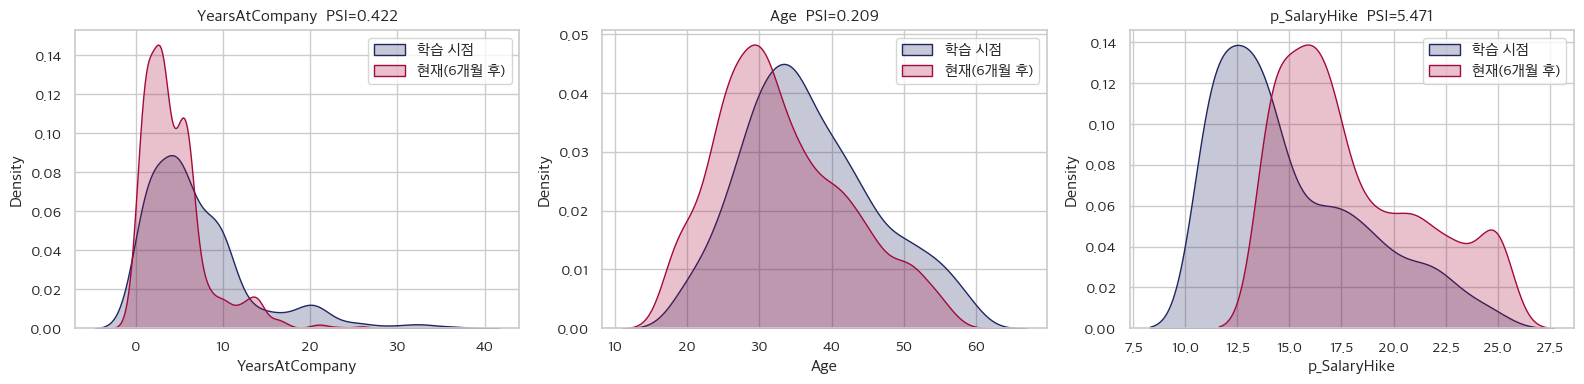

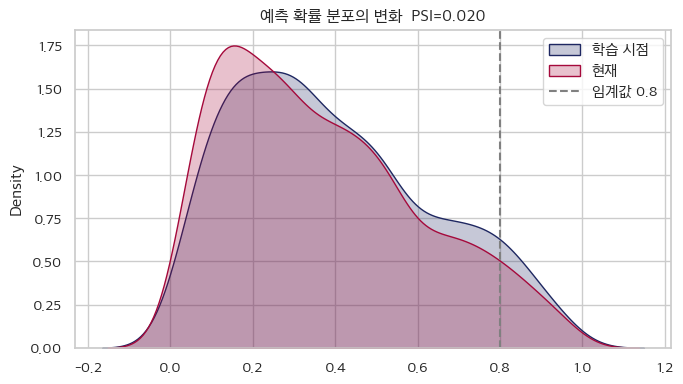

학습 시점 선정률 : 0.073
현재 선정률      : 0.060
→ 선정률이 크게 변했다면, 같은 임계값으로 운영 부하가 달라진다는 뜻이다.


In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cur_fe = add_features(current)
for ax, col in zip(axes, ["YearsAtCompany", "Age", "p_SalaryHike"]):
    sns.kdeplot(X_train[col], ax=ax, label="학습 시점", color="#1E2761", fill=True, alpha=0.25)
    sns.kdeplot(cur_fe[col], ax=ax, label="현재(6개월 후)", color="#A5093B", fill=True, alpha=0.25)
    ax.set_title(f"{col}  PSI={psi(X_train[col], cur_fe[col]):.3f}")
    ax.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
sns.kdeplot(proba_train, label="학습 시점", color="#1E2761", fill=True, alpha=0.25)
sns.kdeplot(proba_now, label="현재", color="#A5093B", fill=True, alpha=0.25)
plt.axvline(THRESHOLD, ls="--", color="gray", label=f"임계값 {THRESHOLD}")
plt.title(f"예측 확률 분포의 변화  PSI={v_out:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

print(f"학습 시점 선정률 : {(proba_train >= THRESHOLD).mean():.3f}")
print(f"현재 선정률      : {(proba_now >= THRESHOLD).mean():.3f}")
print("→ 선정률이 크게 변했다면, 같은 임계값으로 운영 부하가 달라진다는 뜻이다.")

### 실습 8-2. 재학습 트리거 구현

**주기 기반 + 트리거 기반의 혼합**을 권장한다.
그리고 재학습에는 반드시 **되돌리기(rollback)** 가 함께 설계되어야 한다.


In [90]:
def monitoring_report(train_X, train_proba, new_raw, model, meta,
                      psi_warn=0.10, psi_alert=0.25):
    """월간 모니터링 리포트를 생성하고 재학습 필요 여부를 판정한다."""
    new_fe = add_features(new_raw)
    log = {}

    # 1) 운영 지표 — 시스템이 돌긴 했는가
    log["실행 일시"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
    log["모델 버전"] = meta["model_version"]
    log["대상 건수"] = len(new_raw)
    issues = validate(new_raw, EXPECTED_SCHEMA)
    log["스키마 검증"] = "통과" if not issues else f"실패 ({len(issues)}건)"

    # 2) ML 지표 — 입력 분포가 변했는가
    feat_psi = {c: psi(train_X[c], new_fe[c]) for c in NUM_COLS}
    worst_col = max(feat_psi, key=feat_psi.get)
    worst_psi = feat_psi[worst_col]
    log["최대 입력 PSI"] = f"{worst_col} = {worst_psi:.3f} ({psi_level(worst_psi)})"

    # 3) ML 지표 — 그 변화가 출력과 운영 부하까지 바꿨는가
    p_now = model.predict_proba(new_fe[meta["input_columns"]])[:, 1]
    out_psi = psi(train_proba, p_now)
    log["출력 PSI"] = f"{out_psi:.3f} ({psi_level(out_psi)})"
    log["선정률 변화"] = (f"{(train_proba >= meta['threshold']).mean():.3f} → "
                       f"{(p_now >= meta['threshold']).mean():.3f}")

    # 4) 판정 — 사람이 읽고 바로 행동할 수 있는 한 줄로 끝낸다
    reasons = []
    if issues:
        reasons.append("스키마 검증 실패")
    if worst_psi >= psi_alert:
        reasons.append(f"입력 드리프트 경보 ({worst_col})")
    if out_psi >= psi_alert:
        reasons.append("출력 드리프트 경보")

    log["판정"] = "재학습 필요 🔴" if reasons else (
        "관찰 필요 🟡" if (worst_psi >= psi_warn or out_psi >= psi_warn) else "정상 🟢")
    log["사유"] = ", ".join(reasons) if reasons else "-"
    return log


# 정상 데이터와 드리프트 데이터를 같은 함수로 통과시켜 비교한다
normal = df.sample(len(current), replace=True, random_state=7)

for label, dataset in [("정상 데이터 (분포 변화 없음)", normal),
                       ("드리프트 데이터 (6개월 후)", current)]:
    print("=" * 58)
    print(f" {label}")
    print("=" * 58)
    for k, v in monitoring_report(X_train, proba_train, dataset, clf, meta).items():
        print(f"   {k:12s}: {v}")
    print()

print("→ 같은 코드가 한쪽은 '정상', 다른 쪽은 '재학습 필요'로 판정한다.")
print("  모니터링의 산출물은 그래프가 아니라 '무엇을 할 것인가' 한 줄이어야 한다.")

 정상 데이터 (분포 변화 없음)
   실행 일시       : 2026-09-22 17:28
   모델 버전       : v1
   대상 건수       : 1470
   스키마 검증      : 통과
   최대 입력 PSI   : Age = 0.008 (정상)
   출력 PSI      : 0.007 (정상)
   선정률 변화      : 0.073 → 0.060
   판정          : 정상 🟢
   사유          : -

 드리프트 데이터 (6개월 후)
   실행 일시       : 2026-09-22 17:28
   모델 버전       : v1
   대상 건수       : 1470
   스키마 검증      : 통과
   최대 입력 PSI   : p_SalaryHike = 5.471 (경보)
   출력 PSI      : 0.020 (정상)
   선정률 변화      : 0.073 → 0.060
   판정          : 재학습 필요 🔴
   사유          : 입력 드리프트 경보 (p_SalaryHike)

→ 같은 코드가 한쪽은 '정상', 다른 쪽은 '재학습 필요'로 판정한다.
  모니터링의 산출물은 그래프가 아니라 '무엇을 할 것인가' 한 줄이어야 한다.


In [91]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — monitoring_report() 모니터링 리포트
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    def monitoring_report(train_X, train_proba, new_raw, model, meta,
                          psi_warn=0.10, psi_alert=0.25):
        new_fe = add_features(new_raw)
        log = {"실행 일시": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
               "모델 버전": meta["model_version"], "대상 건수": len(new_raw)}
        issues = validate(new_raw, EXPECTED_SCHEMA)
        log["스키마 검증"] = "통과" if not issues else f"실패 ({len(issues)}건)"

        feat_psi = {c: psi(train_X[c], new_fe[c]) for c in NUM_COLS}
        worst_col = max(feat_psi, key=feat_psi.get)
        log["최대 입력 PSI"] = f"{worst_col} = {feat_psi[worst_col]:.3f} ({psi_level(feat_psi[worst_col])})"

        p_now = model.predict_proba(new_fe[meta["input_columns"]])[:, 1]
        out_psi = psi(train_proba, p_now)
        log["출력 PSI"] = f"{out_psi:.3f} ({psi_level(out_psi)})"
        log["선정률 변화"] = (f"{(train_proba >= meta['threshold']).mean():.3f} → "
                           f"{(p_now >= meta['threshold']).mean():.3f}")

        reasons = []
        if issues:
            reasons.append("스키마 검증 실패")
        if feat_psi[worst_col] >= psi_alert:
            reasons.append(f"입력 드리프트 경보 ({worst_col})")
        if out_psi >= psi_alert:
            reasons.append("출력 드리프트 경보")
        log["판정"] = "재학습 필요 🔴" if reasons else (
            "관찰 필요 🟡" if (feat_psi[worst_col] >= psi_warn or out_psi >= psi_warn) else "정상 🟢")
        log["사유"] = ", ".join(reasons) if reasons else "-"
        return log

    print("monitoring_report() 준비 완료")
    print('⚠ 구제 코드를 사용했습니다 — monitoring_report() 모니터링 리포트')

### 실습 8-3. 재학습과 롤백  〔읽기 · 코드 제공〕

**새 모델이 항상 더 낫지는 않다.** 재학습 후 이전 모델과 성능을 비교하고, 나빠졌다면 배포하지 않는다.


In [92]:
def retrain_and_compare(old_model, X_tr, y_tr, X_va, y_va, threshold):
    """재학습 후 이전 모델과 비교해 배포 여부를 결정한다."""
    new_model = Pipeline([("pre", make_preprocessor()),
                          ("model", LogisticRegression(max_iter=1000,
                                                       class_weight="balanced",
                                                       random_state=RANDOM_STATE))])
    new_model.fit(X_tr, y_tr)

    def score(m):
        p = (m.predict_proba(X_va)[:, 1] >= threshold).astype(int)
        return {"재현율": recall_score(y_va, p, zero_division=0),
                "정밀도": precision_score(y_va, p, zero_division=0),
                "ROC-AUC": roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])}

    old_s, new_s = score(old_model), score(new_model)
    table = pd.DataFrame([{"모델": "v1 (기존)", **old_s}, {"모델": "v2 (재학습)", **new_s}]).round(4)
    deploy = new_s["재현율"] >= old_s["재현율"] - 0.02      # 허용 하락폭 2%p
    table["결정"] = ["유지" if not deploy else "교체 대상",
                    "배포 ✅" if deploy else "배포 보류 → 롤백 🔙"]
    return table


retrain_and_compare(clf, X_train, y_train, X_valid, y_valid, THRESHOLD)

,모델,재현율,정밀도,ROC-AUC,결정
0,v1 (기존),0.2958,0.7241,0.8174,교체 대상
1,v2 (재학습),0.2958,0.7241,0.8174,배포 ✅


---
# 9. 통합 — 7단계로 완성한 시스템 (수업 · 코드 제공)

아래 셀은 **월 1회 배치 작업 전체**를 한 번에 실행한다.
데이터 검증 → 예측 → 결과 저장 → 모니터링 → 재학습 판정.


In [93]:
def monthly_job(raw_data, service, train_X, train_proba, meta, top_k=30):
    print("=" * 62)
    print(f" HR 이직 위험 예측 — 월간 배치 작업  ({pd.Timestamp.now():%Y-%m-%d %H:%M})")
    print("=" * 62)

    # 1) 데이터 검증 → 실패하면 예측하지 않는다
    issues = validate(raw_data, EXPECTED_SCHEMA)
    if issues:
        print("[중단] 입력 데이터 검증 실패 — 담당자에게 알림")
        for i in issues:
            print("   -", i)
        return None

    # 2) 예측
    result = service.predict_batch(raw_data)
    print(f"[예측] {len(result):,}건 완료 / 모델 {service.version} / 임계값 {service.threshold}")
    print(f"       면담 대상(flag=1): {int(result['flag'].sum())}명 "
          f"({result['flag'].mean():.1%})")

    # 3) 결과 저장 — 기록이 없으면 나중에 성능을 되짚을 수 없다
    result.to_csv("predictions_latest.csv", encoding="utf-8-sig")
    print("[저장] predictions_latest.csv")

    # 4) 모니터링
    print("\n[모니터링]")
    for k, v in monitoring_report(train_X, train_proba, raw_data,
                                  service.model, meta).items():
        print(f"   {k:12s}: {v}")

    # 5) 인사팀 제공 명단
    print(f"\n[면담 대상 상위 {top_k}명]")
    print(result.head(top_k)[["risk", "flag"]].head(5))
    print("   ...")
    return result


_ = monthly_job(current, service, X_train, proba_train, meta)

 HR 이직 위험 예측 — 월간 배치 작업  (2026-09-22 17:28)
[예측] 1,470건 완료 / 모델 v1 / 임계값 0.8
       면담 대상(flag=1): 88명 (6.0%)
[저장] predictions_latest.csv

[모니터링]
   실행 일시       : 2026-09-22 17:28
   모델 버전       : v1
   대상 건수       : 1470
   스키마 검증      : 통과
   최대 입력 PSI   : p_SalaryHike = 5.471 (경보)
   출력 PSI      : 0.020 (정상)
   선정률 변화      : 0.073 → 0.060
   판정          : 재학습 필요 🔴
   사유          : 입력 드리프트 경보 (p_SalaryHike)

[면담 대상 상위 30명]
        risk  flag
271   0.9722     1
1130  0.9685     1
1418  0.9684     1
772   0.9683     1
1240  0.9674     1
   ...


---
# 산출물 ⑤ 시스템 설계 문서

아래 표를 직접 채워라. **오른쪽 '근거' 열이 이 문서의 핵심**이다.

| 단계 | 이 사례에서 내린 결정 | 근거 |
|---|---|---|
| 1 요구사항 명확화 | | |
| 2 문제 구조화 | | |
| 3 데이터 준비 | | |
| 4 모델 개발 | | |
| 5 평가 | | |
| 6 배포 | | |
| 7 모니터링 | | |

### 추가로 답할 것

1. 이 시스템에서 **가장 위험한 실패 시나리오**는 무엇인가? 어떻게 방지하는가?
2. 예측이 개입을 부르고, 개입이 결과를 바꾼다. 그러면 다음 학습 데이터는 이미 이전 모델의 영향을 받은 데이터다.
   이 **피드백 루프**를 어떻게 감지하고 다룰 것인가?
3. 6개월 뒤 이 시스템을 인수인계받은 사람이 알아야 할 것 3가지는 무엇인가?

---
# 제출

1. 모든 TODO 셀을 채우고 **런타임 → 모두 실행**이 오류 없이 끝나는지 확인한다.
2. **3주간의 노트북 3개 + 시스템 설계 문서 1부**를 제출한다.
3. 설계 문서에는 각 결정의 **근거**가 반드시 포함되어야 한다.

## 다음 차시 (5차시) 예고 — 시각 검색 시스템

데이터가 표에서 이미지로 바뀐다.
- 지표: Precision@k · nDCG
- 모델: 임베딩 + 근사 최근접 이웃(ANN) 탐색
- 배포: 대규모 온라인 서빙

**그러나 순서는 오늘까지 세 번 반복한 7단계 그대로다.**
